In [ ]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(x_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)


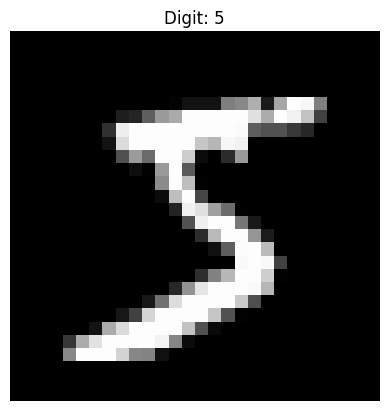

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0], cmap='gray')
plt.title(f"Digit: {y_train[0]}")
plt.axis('off')
plt.show()

In [ ]:
print("Training Images Shape:", x_train.shape)
print("Testing Images Shape:", x_test.shape)

print("Maximum Pixel Value:", x_train.max())
print("Minimum Pixel Value:", x_train.min())

Training Images Shape: (60000, 28, 28)
Testing Images Shape: (10000, 28, 28)
Maximum Pixel Value: 255
Minimum Pixel Value: 0


In [ ]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [ ]:
print("Maximum Pixel:", x_train.max())
print("Minimum Pixel:", x_train.min())

Maximum Pixel: 1.0
Minimum Pixel: 0.0


In [ ]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [ ]:
print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)

Training Shape: (60000, 28, 28, 1)
Testing Shape: (10000, 28, 28, 1)


In [ ]:
import numpy as np

noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

In [ ]:
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

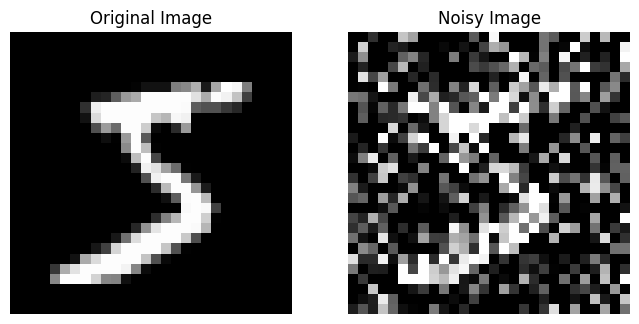

In [ ]:
plt.figure(figsize=(8,4))

# Original Image
plt.subplot(1,2,1)
plt.imshow(x_train[0].reshape(28,28), cmap='gray')
plt.title("Original Image")
plt.axis("off")

# Noisy Image
plt.subplot(1,2,2)
plt.imshow(x_train_noisy[0].reshape(28,28), cmap='gray')
plt.title("Noisy Image")
plt.axis("off")

plt.show()

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

In [ ]:
input_img = Input(shape=(28,28,1))

x = Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    padding='same'
)(input_img)

x = MaxPooling2D(
    pool_size=(2,2),
    padding='same'
)(x)

x = Conv2D(
    filters=16,
    kernel_size=(3,3),
    activation='relu',
    padding='same'
)(x)

encoded = MaxPooling2D(
    pool_size=(2,2),
    padding='same'
)(x)

In [ ]:
x = Conv2D(
    filters=16,
    kernel_size=(3,3),
    activation='relu',
    padding='same'
)(encoded)

x = UpSampling2D((2,2))(x)

x = Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    padding='same'
)(x)

x = UpSampling2D((2,2))(x)

decoded = Conv2D(
    filters=1,
    kernel_size=(3,3),
    activation='sigmoid',
    padding='same'
)(x)

In [ ]:
autoencoder = Model(input_img, decoded)

In [ ]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

In [ ]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 69s 145ms/step - loss: 0.1828 - val_loss: 0.1252
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 145ms/step - loss: 0.1213 - val_loss: 0.1157
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 145ms/step - loss: 0.1149 - val_loss: 0.1113
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 69s 148ms/step - loss: 0.1114 - val_loss: 0.1086
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 146ms/step - loss: 0.1091 - val_loss: 0.1068
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 70s 148ms/step - loss: 0.1072 - val_loss: 0.1052
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 69s 146ms/step - loss: 0.1058 - val_loss: 0.1041
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 145ms/step - loss: 0.1047 - val_loss: 0.1030
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 145ms/step - loss: 0.1037 - val_loss: 0.1027
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 145ms/step - loss: 0.1029 - val_loss: 0.1020
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 146ms/step - loss: 0.1025 - val_loss: 0.1021
Epoch 12/20
469/469

In [ ]:
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


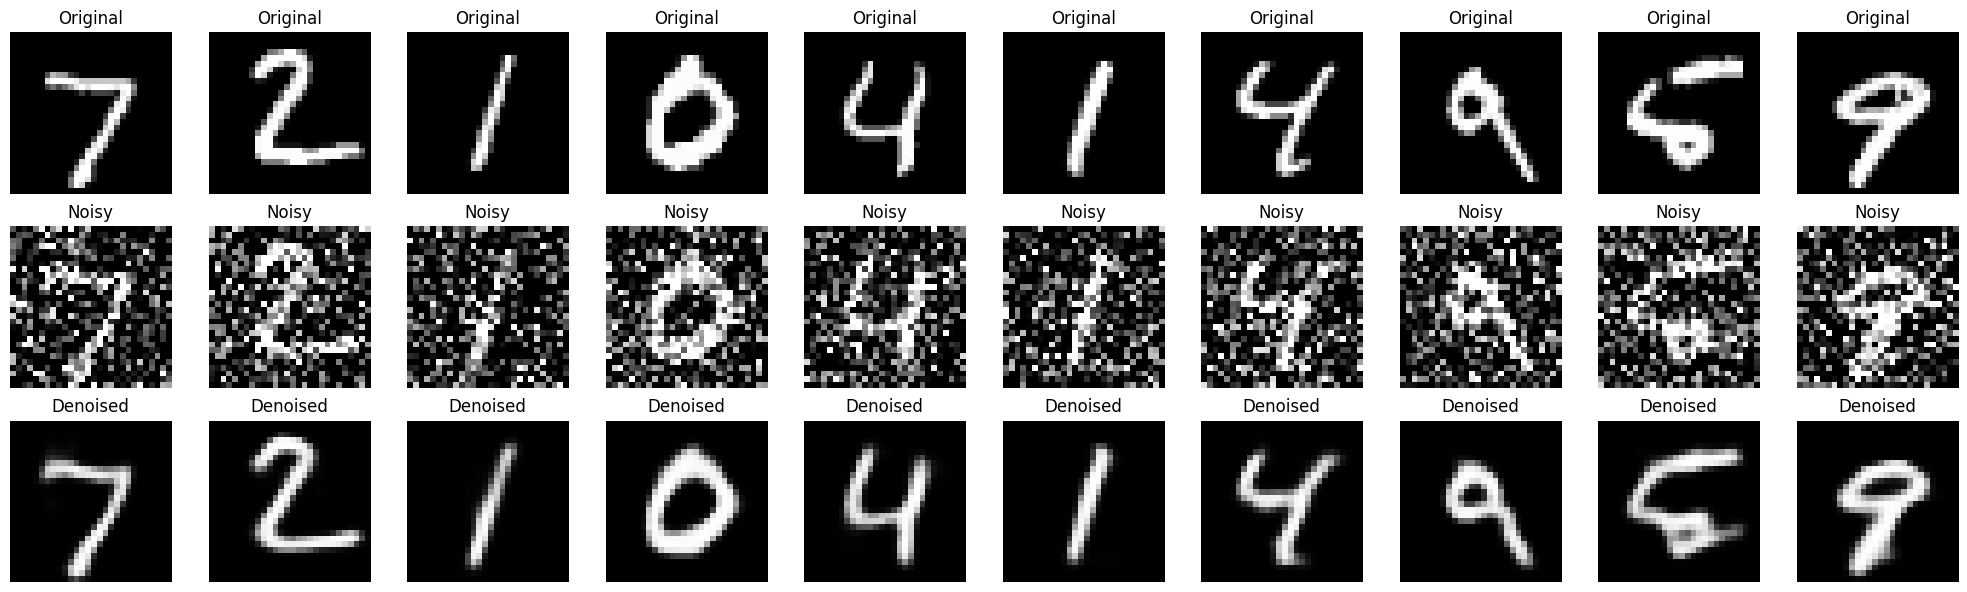

In [ ]:
import matplotlib.pyplot as plt

n = 10
plt.figure(figsize=(20, 6))

for i in range(n):

    # Original Image
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy Image
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised Image
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.tight_layout()
plt.show()

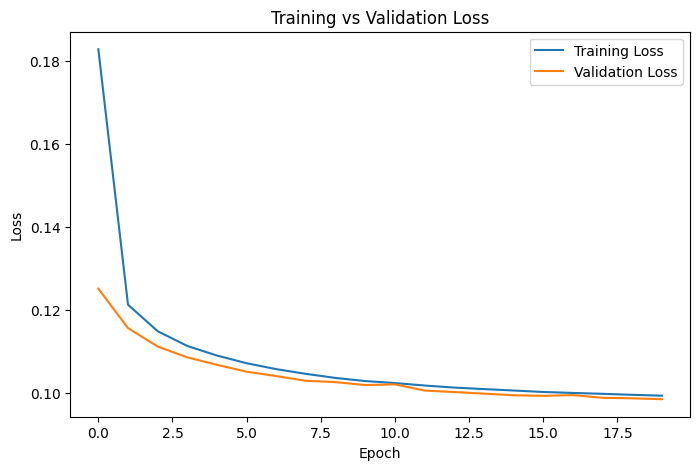

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()